# Introduction

This is the basic reproduction experiment for Yao et al., "Dynamic Word Embeddings for Evolving Semantic Discovery".
It is based on the source code provided in their
[GitHub repository](https://github.com/yifan0sun/DynamicWord2Vec)
and aims to simplify the experiment, update it to a modern Python setup, and ultimately validate the findings from the authors.

# Setup

In [ ]:
import os
if os.getcwd() != '/home/jovyan/Semantic-Embedding-Evolution':
    os.chdir('Semantic-Embedding-Evolution')

'/home/jovyan/Semantic-Embedding-Evolution'

## Imports

In [1]:
# file io
import scipy.io as sio

# machine learning
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# analyses and plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

## Data setup
The experiment relies on files from the researchers dropbox folder. These files are saved in the data directory first.

In [2]:
%run ../setup/setup.py

Exception: File `'../setup/setup.py'` not found.

## Static variables

In [3]:
seed = 42
years = range(1990, 2017)
vocab_size = 20936
embeddings_file = "../data/emb_static.mat"
word_id_file = "../data/wordIDHash.csv"
train_path = "../data/pmi_"

## Use GPU if possible

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Setup static embeddings

In [5]:
static_embeddings = sio.loadmat(embeddings_file)["emb"]
static_embeddings = torch.from_numpy(static_embeddings).float()

## Word to id mapping
The PMI (pointwise mutual information) is stored in an indexed form. The wordIdHash table holds the id for each word.

In [6]:
df_word_id = pd.read_csv(word_id_file, header=None, names=["id", "word", "count"])

wordlist = [f"missing_word_idx_{i}" for i in range(vocab_size)]

for _, row in df_word_id.iterrows():
    wordlist[int(row["id"])] = str(row["word"])

word2Id = {word: i for i, word in enumerate(wordlist)}

# Dataset
The authors of the study provide the data in MATLAB files. Each PMI file contains the PMI for the word combinations that occur together. The data is very large, so it is not possible to preload it all. However, for slight performance increases, we can load the dense format of the data to the GPU.

In [7]:
class PMIDataset(Dataset):
    def __init__(self, time_steps, train_path, vocab_size):
        self.time_steps = time_steps
        self.train_path = train_path
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.time_steps)

    def __getitem__(self, idx):
        t_idx = self.time_steps[idx]
        file_path = f"{train_path}{t_idx}.mat"

        pmi = sio.loadmat(file_path)["pmi"]
        pmi = torch.from_numpy(pmi.toarray()).float()

        return t_idx, pmi

In [8]:
dataset = PMIDataset(range(len(years)), train_path, vocab_size)
loader = DataLoader(dataset, batch_size=1)

# Model
The original study does manual gradient calculation, which is not necessary in the PyTorch framework.
Instead, only the loss is calculated with the same components as in Yao et al.

In [9]:
class DynamicEmbeddingModel(nn.Module):
    def __init__(self, n_years, initial_emb):
        super().__init__()
        self.U = nn.Parameter(initial_emb.unsqueeze(0).repeat(n_years, 1, 1))
        self.V = nn.Parameter(initial_emb.unsqueeze(0).repeat(n_years, 1, 1))

    def forward(self, y_idx, pmi, tau, gam, emph):
        # estimate embeddings for specific year
        U_t = self.U[y_idx]
        V_t = self.V[y_idx]
        pred = torch.matmul(U_t, V_t.t())

        # calculate reconstruction loss emphasisizing cooccurring words (non-zero pmi) using emph
        mask = (pmi > 0).float()
        weight_matrix = mask * emph + (1 - mask)
        reconstruction_loss = torch.sum(weight_matrix * torch.square(pmi - pred))

        # penalize dealignment with gamma
        alignment_loss = gam * torch.sum(torch.square(U_t - V_t))

        # penalize temporal change of embedding with tau
        temporal_loss = 0
        if y_idx > 0:
            temporal_loss = tau * torch.sum(torch.square(U_t - self.U[y_idx - 1]))

        return reconstruction_loss + alignment_loss + temporal_loss

    @torch.no_grad()
    def get_drift(self, word_idx):
        start_vec = self.U[0, word_idx]
        end_vec = self.U[-1, word_idx]

        cos_sim = torch.cosine_similarity(start_vec, end_vec, dim=0).item()
        drift_norm = torch.norm(start_vec - end_vec).item()

        return drift_norm, cos_sim

# Training

## Hyperparameters

- **lam**: L2 regularizer penalizing large weights
- **tau**: Penalty for weight differences between years
- **gam**: Penalty for misalignment between U and V
- **emph**: Factor for loss corresponding to words that really cooccured in the PMI data


In [11]:
n_epochs = 25
lam = 1
tau = 0.005
gam = 0.5
emph = 5000
learning_rate = 2e-3
weight_decay = 1e-5

## Training procedure

In [12]:
model = DynamicEmbeddingModel(len(years), static_embeddings).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

for epoch in range(n_epochs):
    model.train()
    # shuffle to prevent temporal bias in training
    indices = torch.randperm(len(years))

    # fit to each year individually
    epoch_loss = 0
    for y_idx in indices:
        _, pmi = dataset[y_idx.item()]
        pmi = pmi.to(device)

        # forward pass
        optimizer.zero_grad()
        loss = model(y_idx.item(), pmi, tau=tau, gam=gam, emph=emph)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip gradients for stability

        optimizer.step()
        epoch_loss += loss.item()

    # monitor change of embeddings for reference word 'amazon'
    drift, sim = model.get_drift(word2Id["amazon"])
    print(f"Epoch {epoch} | Loss: {epoch_loss/len(years):.2f} | Drift: {drift:.4f} | Cosine Similarity: {sim:.4f}")

print("Training finished")

Epoch 0 | Loss: 215556955856.59 | Drift: 0.2067 | Cosine Similarity: 0.9964
Epoch 1 | Loss: 210891378839.70 | Drift: 0.2871 | Cosine Similarity: 0.9910
Epoch 2 | Loss: 206389920047.41 | Drift: 0.3545 | Cosine Similarity: 0.9845
Epoch 3 | Loss: 201787489697.19 | Drift: 0.4287 | Cosine Similarity: 0.9763
Epoch 4 | Loss: 196918032004.74 | Drift: 0.4980 | Cosine Similarity: 0.9677
Epoch 5 | Loss: 191942218486.52 | Drift: 0.5576 | Cosine Similarity: 0.9593
Epoch 6 | Loss: 186051294852.74 | Drift: 0.6243 | Cosine Similarity: 0.9507
Epoch 7 | Loss: 179470275621.93 | Drift: 0.6673 | Cosine Similarity: 0.9436
Epoch 8 | Loss: 171901908005.93 | Drift: 0.7238 | Cosine Similarity: 0.9359
Epoch 9 | Loss: 163666349624.89 | Drift: 0.7960 | Cosine Similarity: 0.9254
Epoch 10 | Loss: 154672550343.11 | Drift: 0.8376 | Cosine Similarity: 0.9177
Epoch 11 | Loss: 145393710117.93 | Drift: 0.9184 | Cosine Similarity: 0.9038
Epoch 12 | Loss: 136128136685.04 | Drift: 1.0001 | Cosine Similarity: 0.8899
Epoch 13 

# Output visualization

## Example embedding over time

In [20]:
def plot_word_embedding_trajectory(word, model=model, word2Id=word2Id, years=years, old_meaning=[], new_meaning=[]):
    # get word ids
    word_idx = word2Id[word]
    old_indices = [word2Id[w] for w in old_meaning if w in word2Id]
    new_indices = [word2Id[w] for w in new_meaning if w in word2Id]

    # generate embeddings
    model.eval()
    with torch.no_grad():
        embs = model.U[list(range(len(years))), word_idx, :].detach().cpu().numpy()
        old_embs = model.U[0, old_indices, :].detach().cpu().numpy() if old_indices else np.empty((0, embs.shape[1]))
        new_embs = model.U[-1, new_indices, :].detach().cpu().numpy() if new_indices else np.empty((0, embs.shape[1]))

    # combine all embeddings
    all_to_plot = np.vstack([embs, old_embs, new_embs])

    # calculate TSNE
    current_perplexity = min(5, len(all_to_plot) - 1)
    tsne = TSNE(n_components=2, perplexity=current_perplexity, random_state=seed, init="pca")
    Z_all = tsne.fit_transform(all_to_plot)

    # split results
    Z = Z_all[:len(years)]
    Z_old = Z_all[len(years):len(years) + len(old_indices)]
    Z_new = Z_all[len(years) + len(old_indices):]

    # plot
    plt.figure(figsize=(10, 6))
    plt.plot(Z[:, 0], Z[:, 1], linestyle="--", color="gray", alpha=0.5)

    # keyword trajectory
    for i, year in enumerate(years):
        plt.scatter(Z[i, 0], Z[i, 1], color="red", s=100, edgecolors="black")
        plt.text(Z[i, 0] + 0.05, Z[i, 1] + 0.05, f"{year}", fontsize=9)

    # old meaning reference points
    for i, w in enumerate(old_meaning):
        if i < len(Z_old):
            plt.scatter(Z_old[i, 0], Z_old[i, 1], color="green", marker="X", s=150, edgecolors="black")
            plt.text(Z_old[i, 0] + 0.05, Z_old[i, 1] + 0.05, w, color="green", fontweight='bold')

    # new meaning reference points
    for i, w in enumerate(new_meaning):
        if i < len(Z_new):
            plt.scatter(Z_new[i, 0], Z_new[i, 1], color="blue", marker="X", s=150, edgecolors="black")
            plt.text(Z_new[i, 0] + 0.05, Z_new[i, 1] + 0.05, w, color="blue", fontweight='bold')

    plt.title(f"Semantic Drift Trajectory for '{word}' from {years[0]} until {years[-1]}")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

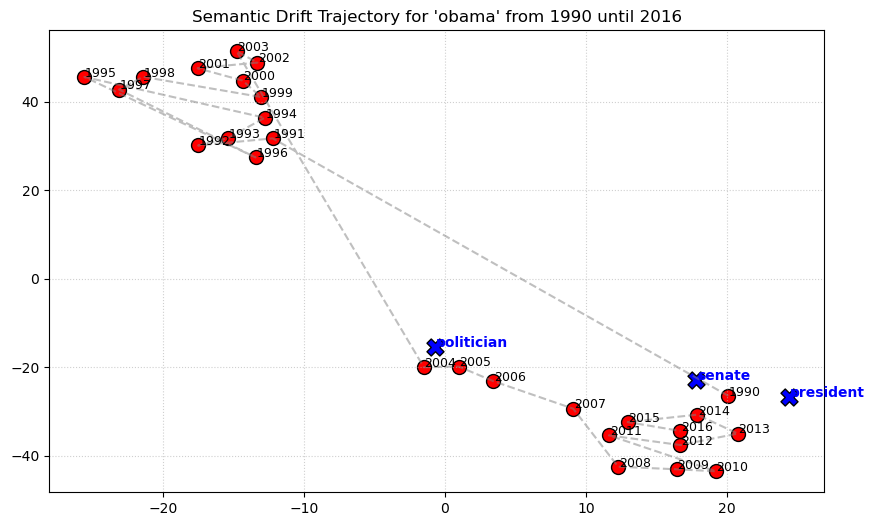

In [21]:
plot_word_embedding_trajectory("obama", new_meaning=["president", "senate", "politician"])

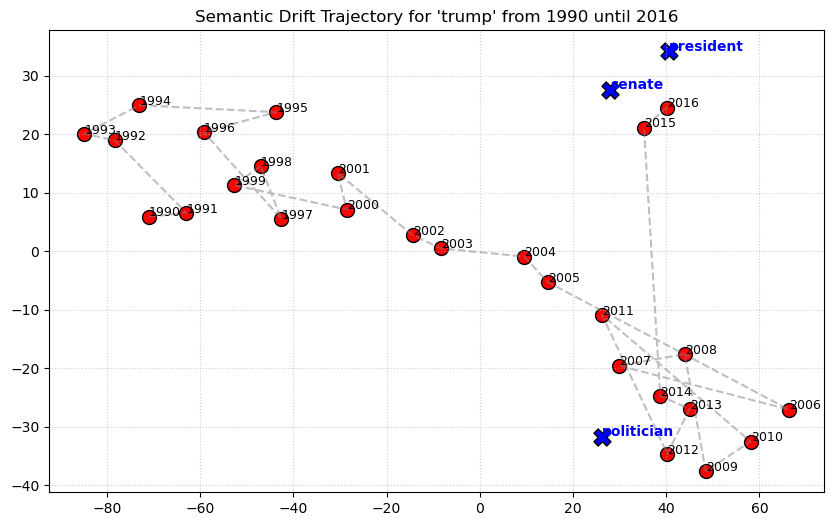

In [15]:
plot_word_embedding_trajectory("trump", new_meaning=["president", "senate", "politician"])

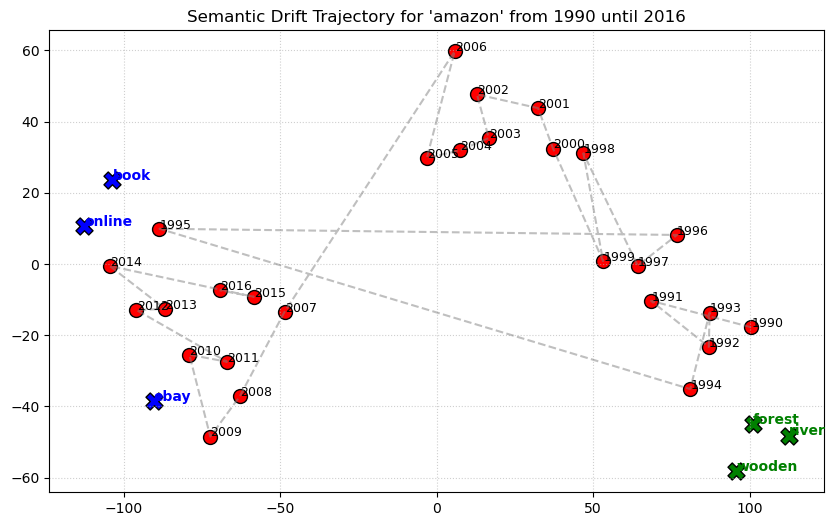

In [28]:
plot_word_embedding_trajectory(
    "amazon",
    old_meaning=["forest", "wooden", "river"],
    new_meaning=["book", "online", "ebay"]
)

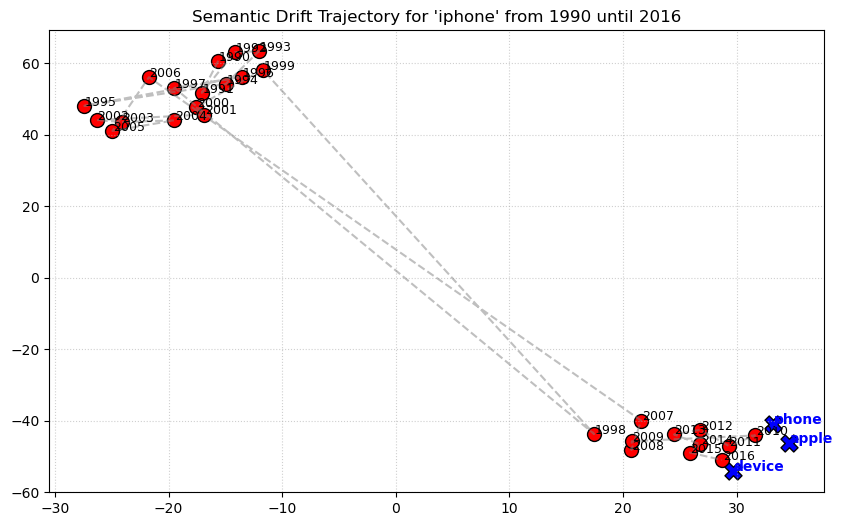

In [32]:
plot_word_embedding_trajectory("iphone", new_meaning=["phone", "device", "apple"])

## Closest words over time

In [23]:
def get_temporal_neighbors(word, model=model, word2Id=word2Id, wordlist=wordlist, years=years, top_n=5):
    word_idx = word2Id[word]
    results = []
    model.eval()

    with torch.no_grad():
        all_U = model.U.detach().cpu()

        for i, year in enumerate(years):
            word_embedding = all_U[i]

            # use cosine similarity as measure of semantic closeness
            sims = torch.nn.functional.cosine_similarity(word_embedding[word_idx].unsqueeze(0), word_embedding)

            # take top_n indices
            _, indices = torch.topk(sims, top_n + 2)

            # map to neighbor words
            neighbors = [wordlist[idx] for idx in indices.tolist()
                             if wordlist[idx].lower() != word.lower()][:top_n]

            results.append({"Year": year, "Top Neighbors": ", ".join(neighbors)})

    return pd.DataFrame(results)

In [29]:
get_temporal_neighbors("trump", top_n=5).set_index("Year").T

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
Top Neighbors,"gingrich, bid, strategists, candidacy, newt","dole, bid, endorsement, personally, quayle","perry, gingrich, forbes, endorsement, suggestion","hillary, clintons, perot, hack, dislike","perry, rep, folks, gore, suggestion","perot, romney, mitt, gore, bet","frankly, mccain, congressman, endorsement, perry","ridiculous, koch, donald, insiders, echoed","gore, mccain, hillary, candidacy, gingrich","hillary, frankly, candidacy, establishment, fo...",...,"campaigning, mitt, frankly, advertisement, seg...","gentlemen, mitt, arguably, forbes, christie","dole, hillary, endorsement, outrageous, gingrich","romney, mitt, gingrich, gore, rubio","hillary, mitt, huckabee, santorum, palin","palin, endorsement, hillary, frankly, candidacy","hillary, shepard, perot, suggestion, gore","romney, gore, barack, mitt, mccain","candidate, candidates, presidential, hillary, ...","candidate, party, cruz, campaign, republican"


In [25]:
get_temporal_neighbors("obama", top_n=5).set_index("Year").T

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
Top Neighbors,"barack, giuliani, romney, pataki, committee","bloomberg, clintons, blasio, hillary, palin","spitzer, palin, obamacare, obamas, pataki","blasio, palin, jeb, obamas, obamacare","blasio, ensuring, obamacare, bp, obamas","spitzer, blasio, palin, obamas, ensure","spitzer, blasio, palin, corzine, obamas","blasio, jeb, palin, obamacare, obamas","palin, blasio, obamas, obamacare, 2014","palin, obamas, obamacare, blasio, cheney",...,"bush, mccain, debate, campaign, presidential","bush, mccain, campaign, senator, presidential","bush, clinton, campaign, senator, administration","bush, campaign, democrats, republican, republi...","bush, campaign, candidates, romney, republicans","bush, campaign, romney, presidential, debate","bush, campaign, republicans, republican, presi...","bush, campaign, election, republicans, governor","bush, campaign, clinton, presidential, debate","bush, clinton, debate, campaign, presidential"
